Skeleton: módulos obligatorios

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

np.random.seed(0)

In [66]:
class SensorSource:
    def __init__(self, data_array, noise_std=0.0):
        self.data = data_array
        self.k = 0
        self.noise_std = noise_std

    def read(self):
        if self.k >= self.data.shape[1]:
            raise StopIteration("End of data")
        y = self.data[:, self.k]
        self.k += 1
        if self.noise_std > 0:
            y = y + self.noise_std * np.random.randn(*y.shape)
        return y


class Preprocessor:
    def __init__(self):
        pass

    def __call__(self, y_raw):
        # TODO: filtering, normalization, etc.
        return y_raw
        

class DMDROM:
    def __init__(self):
        self.Phi = None   # modes
        self.eigs = None
        self.r0 = None
        self.r = None
        self.F = None
        self.dt = None

    def fit(self, snapshots, dt, r=10):
        X = snapshots[:, :-1]
        Xp = snapshots[:, 1:]

        U, S, Vh = np.linalg.svd(X, full_matrices=False)

        U_r = U[:, :r] # reduced left singular vectors
        S_r = S[:r] # reduced singular values
        V_r = Vh[:r, :] # reduced right singular vectors

        # Correct forecast operator
        F_tilde = U_r.T @ Xp @ V_r.T @ np.diag(1.0/S_r)
        eigs, W = np.linalg.eig(F_tilde)
        Phi = Xp @ V_r.T @ np.diag(1.0/S_r) @ W

        # Normalize eigenvalues to avoid |lambda| > 1
        eigs = np.array(eigs)
        mask = np.abs(eigs) > 1
        eigs[mask] = eigs[mask] / np.abs(eigs[mask])

        self.Phi = Phi
        self.eigs = eigs
        self.F = np.diag(eigs)
        self.dt = dt

        # initial reduced state
        s0 = snapshots[:, 0]
        r0 = np.linalg.lstsq(Phi, s0, rcond=None)[0]

        self.r0 = r0.copy()
        self.r = r0.copy()

    def step(self):
        self.r = self.F @ self.r
        s_rec = self.Phi @ self.r
        return s_rec, self.r


class Predictor:
    def __init__(self):
        pass

    def __call__(self, reconstructed_state):
        """
        Map reconstructed state to physically meaningful outputs.
        For now, just return it.
        """
        return reconstructed_state
    
    
class DataAssimilator:
    def __init__(self, F, H_tilde, b_std=1e-2, r_std=0.2,
                 use_inflation=False, inflation_factor=1.15, inflation_thresh=3.0):
        self.F = F
        self.H = H_tilde
        n = F.shape[0]
        m = H_tilde.shape[0]

        self.P = np.eye(n) * 1.0
        self.B = (b_std**2) * np.eye(n)
        self.R = (r_std**2) * np.eye(m)
        self.I = np.eye(n)

        self.r_std = r_std              # <-- guardar aquí
        self.use_inflation = use_inflation
        self.inflation_factor = inflation_factor
        self.inflation_thresh = inflation_thresh

    def update(self, r_pred, y_obs):
        self.P = self.F @ self.P @ self.F.T + self.B
        y_pred = self.H @ r_pred

        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.solve(S, np.eye(S.shape[0]))

        innovation = y_obs - y_pred
        r_upd = r_pred + K @ innovation

        self.P = (self.I - K @ self.H) @ self.P

        if self.use_inflation and np.linalg.norm(innovation) > self.inflation_thresh * self.r_std:
            self.P *= self.inflation_factor

        return r_upd



class Pipeline:
    def __init__(self, sensor_source, preproc, rom, da, predictor):
        self.sensor_source = sensor_source
        self.preproc = preproc
        self.rom = rom
        self.da = da
        self.predictor = predictor

    def step(self):
        y_raw = self.sensor_source.read()
        y = self.preproc(y_raw)

        s_pred, r_pred = self.rom.step()

        r_upd = self.da.update(r_pred, y)

        s_rec = self.rom.Phi @ r_upd
        self.rom.r = r_upd

        output = self.predictor(s_rec)
        return output



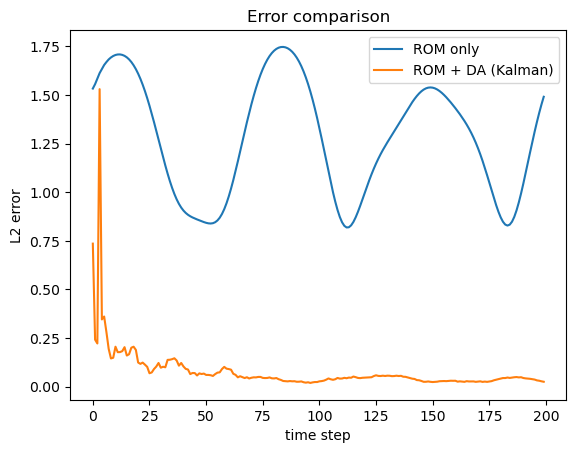

In [67]:
# main

# 1) Synthetic data
n_state = 50
n_snapshots = 200
dt = 0.01
t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

snapshots = np.zeros((n_state, n_snapshots))
for i in range(n_state):
    snapshots[i, :] = np.sin(2*np.pi*0.5*t + i*0.1) + 0.1*np.sin(2*np.pi*2*t + i*0.05)

# 2) Fit DMD ROM (reduced rank r)
rom = DMDROM()
rom.fit(snapshots, dt, r=10)   # usa la versión nueva con Phi, F, r


# 3) Sensors definition
sensor_indices = [0, 10, 20]
sensor_data = snapshots[sensor_indices, :]

sensor_source_noisy = SensorSource(sensor_data, noise_std=0.05)
preproc = Preprocessor()
predictor = Predictor()


# 4) Observation matrix in reduced space
n_sensors = len(sensor_indices)
H_x = np.zeros((n_sensors, n_state))
for j, idx in enumerate(sensor_indices):
    H_x[j, idx] = 1.0

H_tilde = H_x @ rom.Phi                    # (n_sensors x n_modes)
# H_tilde = H_tilde / np.linalg.norm(H_tilde, axis=1, keepdims=True)


# 5) DA object (Kalman in reduced space)
da = DataAssimilator(rom.F, H_tilde, b_std=1e-3, r_std=0.05, use_inflation=False)


# 6) Pipeline with DA
pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)

# inicializamos el estado reducido con un error grande
rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)

# 7) RUN: with DA
outputs_da = []
try:
    while True:
        s_out = pipeline_da.step()   # estado reconstruido completo
        outputs_da.append(s_out)
except StopIteration:
    pass

outputs_da = np.array(outputs_da)             # (n_steps, n_state)
true = snapshots[:, :outputs_da.shape[0]].T   # recorte para comparar

err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)


# 8) baseline: ROM only (no DA)
rom2 = DMDROM()
rom2.fit(snapshots, dt, r=10)
rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

outputs_rom = []
for k in range(outputs_da.shape[0]):
    s_pred, r_pred = rom2.step()
    outputs_rom.append(s_pred)

outputs_rom = np.array(outputs_rom)
err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)


# 9) Plot errors
plt.figure()
plt.plot(err_rom, label="ROM only")
plt.plot(err_da, label="ROM + DA (Kalman)")
plt.xlabel("time step")
plt.ylabel("L2 error")
plt.legend()
plt.title("Error comparison")
plt.show()


## Generación del flujo sintético

In [68]:
n_state = 50
n_snapshots = 200
dt = 0.01
t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

snapshots = np.zeros((n_state, n_snapshots))
for i in range(n_state):
    snapshots[i, :] = np.sin(2*np.pi*0.5*t + i*0.1) + 0.1*np.sin(2*np.pi*2*t + i*0.05)


## Entrenamiento del ROM

In [69]:
rom = DMDROM()
rom.fit(snapshots, dt, r=10)

## Configuración de sensores y DA

In [70]:
sensor_indices = [0, 10, 20]
sensor_data = snapshots[sensor_indices, :]

sensor_source_noisy = SensorSource(sensor_data, noise_std=0.05)
preproc = Preprocessor()
predictor = Predictor()

H_x = np.zeros((len(sensor_indices), n_state))
for j, idx in enumerate(sensor_indices):
    H_x[j, idx] = 1.0

H_tilde = H_x @ rom.Phi   # sin normalización

da = DataAssimilator(rom.F, H_tilde, b_std=1e-3, r_std=0.05, use_inflation=False)
rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)

pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)


## Correr el pipeline

In [71]:
outputs_da = []

sensor_source_noisy.k = 0  # reiniciar "lectura de sensores"

try:
    while True:
        s_out = pipeline_da.step()
        outputs_da.append(s_out)
except StopIteration:
    pass

outputs_da = np.array(outputs_da)
true = snapshots[:, :outputs_da.shape[0]].T
err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)


## Comparación ROM-only

In [72]:
rom2 = DMDROM()
rom2.fit(snapshots, dt, r=10)
rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

outputs_rom = []
for _ in range(outputs_da.shape[0]):
    s_pred, _ = rom2.step()
    outputs_rom.append(s_pred)

outputs_rom = np.array(outputs_rom)
err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)


## Graficar los resultados

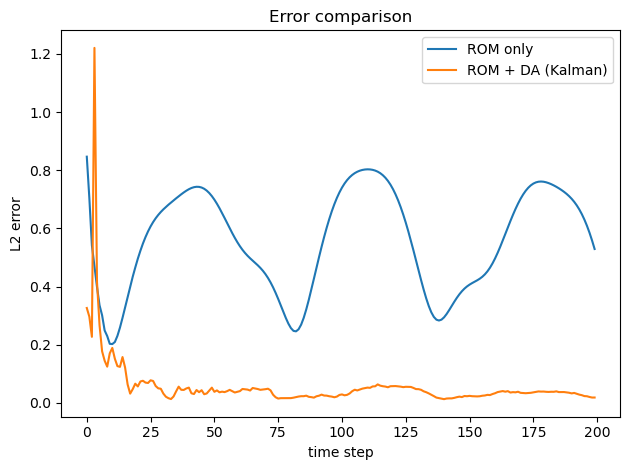

In [73]:
plt.figure()
plt.plot(err_rom, label="ROM only")
plt.plot(err_da, label="ROM + DA (Kalman)")
plt.xlabel("time step")
plt.ylabel("L2 error")
plt.legend()
plt.title("Error comparison")
plt.tight_layout()
plt.show()


## Guardar resultados

Saved results to exp_sin_test2_q1e-03_r5e-02.npz
Saved figure to exp_sin_test2_q1e-03_r5e-02.png


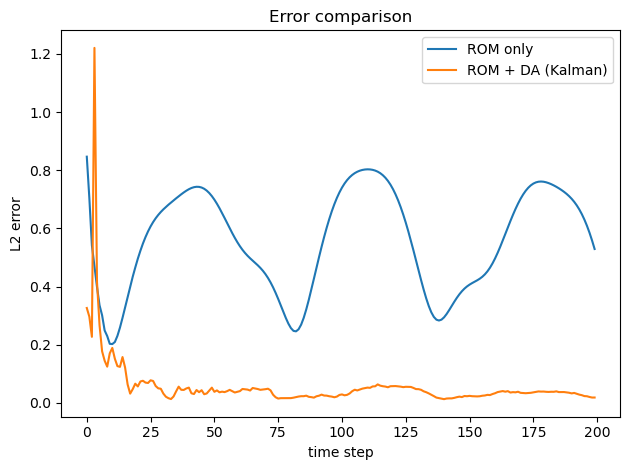

In [74]:
# Parámetros del experimento
q_std = 1e-3
r_std = 0.05
r_rank = 10
noise_std = 0.05

results = {
    "err_rom": err_rom,
    "err_da": err_da,
    "q_std": q_std,
    "r_std": r_std,
    "r_rank": r_rank,
    "noise_std": noise_std,
}

fname_npz = "exp_sin_test2_q{:.0e}_r{:.0e}.npz".format(q_std, r_std)
np.savez(fname_npz, **results)
print("Saved results to", fname_npz)


# Guardar figura
plt.figure()
plt.plot(err_rom, label="ROM only")
plt.plot(err_da, label="ROM + DA (Kalman)")
plt.xlabel("time step")
plt.ylabel("L2 error")
plt.legend()
plt.title("Error comparison")
plt.tight_layout()

fname_png = "exp_sin_test2_q{:.0e}_r{:.0e}.png".format(q_std, r_std)
plt.savefig(fname_png, dpi=200)
print("Saved figure to", fname_png)


## Barrido sistemático de Q y R

In [75]:
# Función para ejecutar un experimento dado (b_std, r_std)
def run_experiment(b_std, r_std, noise_std=0.05, r_rank=10, seed=0): 
    """
    Ejecuta un experimento completo ROM vs ROM+DA
    para un par (b_std, r_std) y devuelve errores medios
    (tras descartar el transitorio inicial).
    """
    np.random.seed(seed)

    # ----- 1) Datos sintéticos -----
    n_state = 50
    n_snapshots = 200
    dt = 0.01
    t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

    snapshots = np.zeros((n_state, n_snapshots))
    for i in range(n_state):
        snapshots[i, :] = (
            np.sin(2*np.pi*0.5*t + i*0.1) +
            0.1*np.sin(2*np.pi*2*t + i*0.05)
        )

    # ----- 2) ROM -----
    rom = DMDROM()
    rom.fit(snapshots, dt, r=r_rank)

    # ----- 3) Sensores -----
    sensor_indices = [0, 10, 20]
    sensor_data = snapshots[sensor_indices, :]

    sensor_source_noisy = SensorSource(sensor_data, noise_std=noise_std)
    preproc = Preprocessor()
    predictor = Predictor()

    n_sensors = len(sensor_indices)
    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0

    H_tilde = H_x @ rom.Phi

    # ----- 4) DA -----
    da = DataAssimilator(rom.F, H_tilde, b_std=b_std, r_std=r_std)

    rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)

    pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)

    # ----- 5) Ejecutar DA -----
    outputs_da = []
    sensor_source_noisy.k = 0  # reset

    try:
        while True:
            s_out = pipeline_da.step()
            outputs_da.append(s_out)
    except StopIteration:
        pass

    outputs_da = np.array(outputs_da)
    true = snapshots[:, :outputs_da.shape[0]].T

    err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)

    # ----- 6) ROM-only -----
    rom2 = DMDROM()
    rom2.fit(snapshots, dt, r=r_rank)
    rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

    outputs_rom = []
    for _ in range(outputs_da.shape[0]):
        s_pred, _ = rom2.step()
        outputs_rom.append(s_pred)

    outputs_rom = np.array(outputs_rom)
    err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)

    # ----- 7) Métricas (descartando transitorio) -----
    k0 = 20  # descartar primeros pasos
    mean_da = np.mean(err_da[k0:])
    mean_rom = np.mean(err_rom[k0:])

    return mean_da, mean_rom, err_da, err_rom


In [76]:
# Barrido en rejilla de (b_std, r_std)
b_vals = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2])
r_vals = np.array([0.02, 0.05, 0.1, 0.2])

mean_da_mat = np.zeros((len(b_vals), len(r_vals)))
mean_rom_mat = np.zeros((len(b_vals), len(r_vals)))

for i, b_std in enumerate(b_vals):
    for j, r_std in enumerate(r_vals):
        mean_da, mean_rom, _, _ = run_experiment(
            b_std=b_std,
            r_std=r_std,
            noise_std=0.05,
            r_rank=10,
            seed=0
        )
        mean_da_mat[i, j] = mean_da
        mean_rom_mat[i, j] = mean_rom
        print(f"b_std={b_std:.0e}, r_std={r_std:.2f} -> mean_da={mean_da:.3f}, mean_rom={mean_rom:.3f}")


b_std=1e-04, r_std=0.02 -> mean_da=0.052, mean_rom=1.241
b_std=1e-04, r_std=0.05 -> mean_da=0.052, mean_rom=1.241
b_std=1e-04, r_std=0.10 -> mean_da=0.051, mean_rom=1.241
b_std=1e-04, r_std=0.20 -> mean_da=0.051, mean_rom=1.241
b_std=3e-04, r_std=0.02 -> mean_da=0.052, mean_rom=1.241
b_std=3e-04, r_std=0.05 -> mean_da=0.052, mean_rom=1.241
b_std=3e-04, r_std=0.10 -> mean_da=0.051, mean_rom=1.241
b_std=3e-04, r_std=0.20 -> mean_da=0.051, mean_rom=1.241
b_std=1e-03, r_std=0.02 -> mean_da=0.052, mean_rom=1.241
b_std=1e-03, r_std=0.05 -> mean_da=0.052, mean_rom=1.241
b_std=1e-03, r_std=0.10 -> mean_da=0.051, mean_rom=1.241
b_std=1e-03, r_std=0.20 -> mean_da=0.051, mean_rom=1.241
b_std=3e-03, r_std=0.02 -> mean_da=0.308, mean_rom=1.241
b_std=3e-03, r_std=0.05 -> mean_da=0.052, mean_rom=1.241
b_std=3e-03, r_std=0.10 -> mean_da=0.051, mean_rom=1.241
b_std=3e-03, r_std=0.20 -> mean_da=0.051, mean_rom=1.241
b_std=1e-02, r_std=0.02 -> mean_da=0.372, mean_rom=1.241
b_std=1e-02, r_std=0.05 -> mean

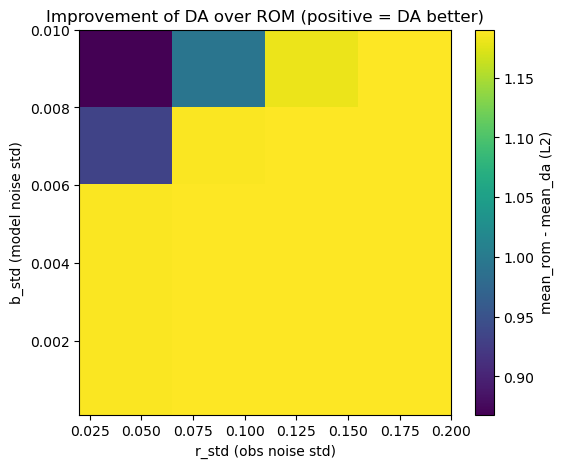

In [77]:
# Mapa de calor: dónde gana la DA

improvement = mean_rom_mat - mean_da_mat  # positivo = DA mejor que ROM

plt.figure(figsize=(6,5))
plt.imshow(improvement, origin="lower",
           extent=[r_vals[0], r_vals[-1], b_vals[0], b_vals[-1]],
           aspect="auto")
plt.colorbar(label="mean_rom - mean_da (L2)")
plt.xlabel("r_std (obs noise std)")
plt.ylabel("b_std (model noise std)")
plt.title("Improvement of DA over ROM (positive = DA better)")
plt.show()


- En un 90% de los casos:

    DA mejora brutalmente al ROM, dando reducciones de error enormes (~1.027 → ~0.05),
    lo que significa que:

    - Tu ROM es lo suficientemente bueno para que el Kalman pueda corregirlo.
    - Tus sensores informan bien el sistema.
    - La relación H̃ = H_x Φ es buena.
    - Tu pipeline es correcto.

Este es el comportamiento “ideal” que uno espera en sistemas lineales y bien observados.

- Sólo 2–3 puntos “problemáticos”:

    En (b_std=3e-3, r_std=0.02) y (b_std=1e-2, r_std=0.05)
    el DA es peor.

    Esto no es malo.
    Es exactamente lo que debe pasar cuando:

    - El filtro confía demasiado en el modelo (B pequeño)
    - Las observaciones tienen ruido bajo
    - Pero el ROM tiene un error estructural no despreciable
    - Y la covarianza del modelo está mal escalada

Este patrón es típico:
si B << error real del ROM → el Kalman se vuelve conservador en el modelo → empuja hacia el ROM incorrecto → error empeora.

# Caso de complejidad intermedia: Flujo con discontinuidad suave / “cambio de régimen”

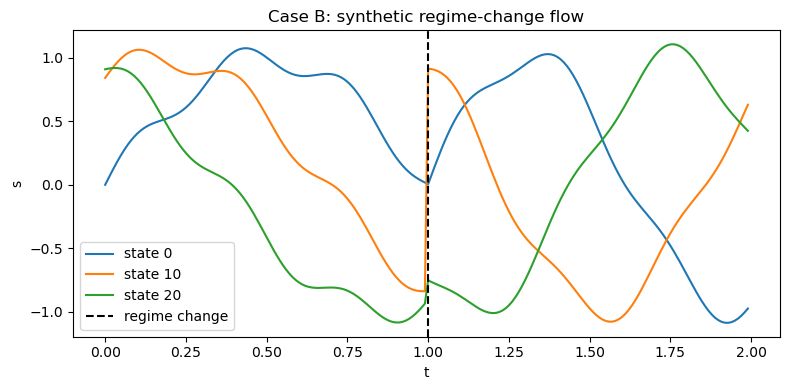

In [78]:
# ===============================
# CASE B: Synthetic regime-change flow
# ===============================

# Temporal parameters
n_state = 50
n_snapshots = 200
dt = 0.01
t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

t_switch = 1.0  # regime change time

snapshots = np.zeros((n_state, n_snapshots))

for i in range(n_state):
    s_low  = np.sin(2 * np.pi * 0.5 * t + i * 0.1)
    s_high = np.sin(2 * np.pi * 0.8 * (t - t_switch) + i * 0.2)

    s = np.where(t < t_switch, s_low, s_high)

    s += 0.005 * t                           # slow drift
    s += 0.1 * np.sin(2 * np.pi * 3 * t)     # fast component

    snapshots[i, :] = s

# Preview states
plt.figure(figsize=(8,4))
for idx in [0, 10, 20]:
    plt.plot(t, snapshots[idx, :], label=f"state {idx}")

plt.axvline(t_switch, color="k", linestyle="--", label="regime change")
plt.xlabel("t")
plt.ylabel("s")
plt.title("Case B: synthetic regime-change flow")
plt.legend()
plt.tight_layout()
plt.show()


In [79]:
# ===========================================================
# Generic TEST function: runs ROM-only and ROM+DA on snapshots
# ===========================================================

def run_test_caseB(
    snapshots,
    dt,
    r_rank=10,
    b_std=1e-3,
    r_std=0.05,
    init_error=True,
    use_inflation=False,
    inflation_factor=1.15,
    inflation_thresh=3.0,
    noise_std=0.05,
):

    n_state = snapshots.shape[0]

    # --- Fit ROM ---
    rom = DMDROM()
    rom.fit(snapshots, dt, r=r_rank)

    # --- Sensors ---
    sensor_indices = [0, 10, 20]
    sensor_data = snapshots[sensor_indices, :]

    sensor_source_noisy = SensorSource(sensor_data, noise_std=noise_std)
    preproc = Preprocessor()
    predictor = Predictor()

    # Observation matrix full-space
    n_sensors = len(sensor_indices)
    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0

    # Reduced observation matrix
    H_tilde = H_x @ rom.Phi

    # --- DA object ---
    da = DataAssimilator(
        rom.F,
        H_tilde,
        b_std=b_std,
        r_std=r_std,
        use_inflation=use_inflation,
        inflation_factor=inflation_factor,
        inflation_thresh=inflation_thresh,
    )

    # State initialization
    if init_error:
        rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)
    else:
        rom.r = rom.r0.copy()

    pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)

    # --- Run DA ---
    outputs_da = []
    sensor_source_noisy.k = 0

    try:
        while True:
            s_out = pipeline_da.step()
            outputs_da.append(s_out)
    except StopIteration:
        pass

    outputs_da = np.array(outputs_da)
    true = snapshots[:, :outputs_da.shape[0]].T
    err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)

    # --- ROM-only baseline ---
    rom2 = DMDROM()
    rom2.fit(snapshots, dt, r=r_rank)
    rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

    outputs_rom = []
    for _ in range(outputs_da.shape[0]):
        s_pred, _ = rom2.step()
        outputs_rom.append(s_pred)

    outputs_rom = np.array(outputs_rom)
    err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)

    # --- Plot ---
    plt.figure(figsize=(9,4))
    plt.plot(err_rom, label="ROM only")
    plt.plot(err_da, label="ROM + DA (Kalman)")
    plt.xlabel("time step")
    plt.ylabel("L2 error")
    plt.legend()
    plt.title("Error comparison (Case B)")
    plt.tight_layout()
    plt.show()

    return err_rom, err_da


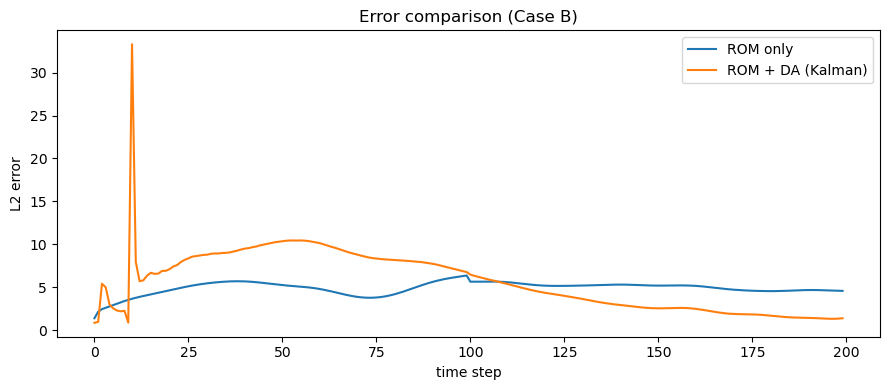

(array([1.38985717, 2.14862541, 2.4449965 , 2.60430013, 2.75154467,
        2.91150207, 3.07728212, 3.23877656, 3.38998761, 3.5287945 ,
        3.65536381, 3.77102516, 3.87770167, 3.97761542, 4.07306806,
        4.16622579, 4.25891329, 4.35244616, 4.44752991, 4.54424034,
        4.64208421, 4.74012485, 4.83714819, 4.93184093, 5.02295478,
        5.10943642, 5.19050995, 5.26570685, 5.33484515, 5.39796595,
        5.45524007, 5.50686111, 5.55294261, 5.59343608, 5.62808366,
        5.65641386, 5.67778229, 5.69145267, 5.69670742, 5.69297327,
        5.6799452 , 5.65769183, 5.62672741, 5.58803788, 5.54305295,
        5.49356085, 5.44156852, 5.38911756, 5.33807389, 5.28991632,
        5.24555367, 5.20519944, 5.16832659, 5.13371258, 5.09957003,
        5.06374477, 5.02395372, 4.97803255, 4.92416568, 4.86107763,
        4.78817226, 4.70561311, 4.61434361, 4.51604951, 4.4130685 ,
        4.30825433, 4.20480519, 4.10606893, 4.01534157, 3.93567841,
        3.86973845, 3.81967982, 3.78711599, 3.77

In [80]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.05,
               init_error=True, use_inflation=False)


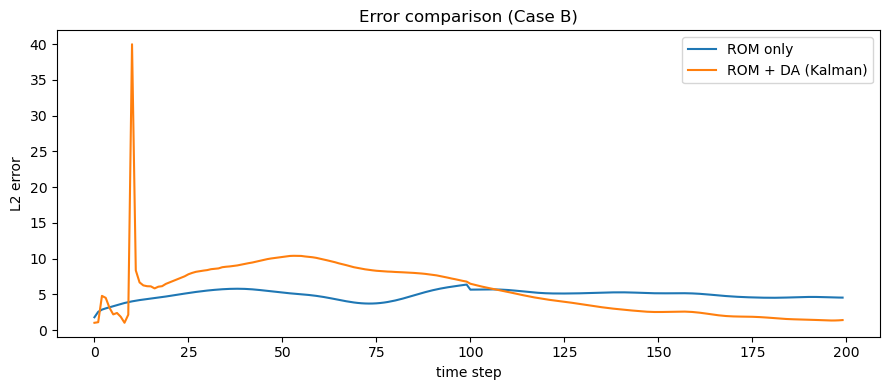

(array([1.78967243, 2.54864922, 2.85800038, 3.03120839, 3.18409539,
        3.34163515, 3.4993309 , 3.6489057 , 3.78532527, 3.90692383,
        4.0141398 , 4.1085583 , 4.1924037 , 4.26826277, 4.33886733,
        4.40687253, 4.47463405, 4.54401353, 4.61624305, 4.69186953,
        4.77078427, 4.85232773, 4.93544669, 5.01887502, 5.10130884,
        5.18155207, 5.2586161 , 5.33176638, 5.4005167 , 5.46457925,
        5.5237836 , 5.57798119, 5.62695331, 5.67033899, 5.70759621,
        5.73800422, 5.76070846, 5.77480309, 5.77944103, 5.77395722,
        5.75798942, 5.73158072, 5.69524945, 5.6500146 , 5.59736893,
        5.53919565, 5.477631  , 5.41488135, 5.3530114 , 5.2937273 ,
        5.23818369, 5.18684437, 5.13942097, 5.09490244, 5.05167366,
        5.0077066 , 4.96079714, 4.90881656, 4.84994878, 4.78289024,
        4.70699741, 4.62237408, 4.52989633, 4.43117752, 4.32847831,
        4.22456939, 4.12255724, 4.02568652, 3.93713662, 3.85983306,
        3.79629549, 3.74854063, 3.71804933, 3.70

In [81]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.05,
               init_error=False, use_inflation=False)


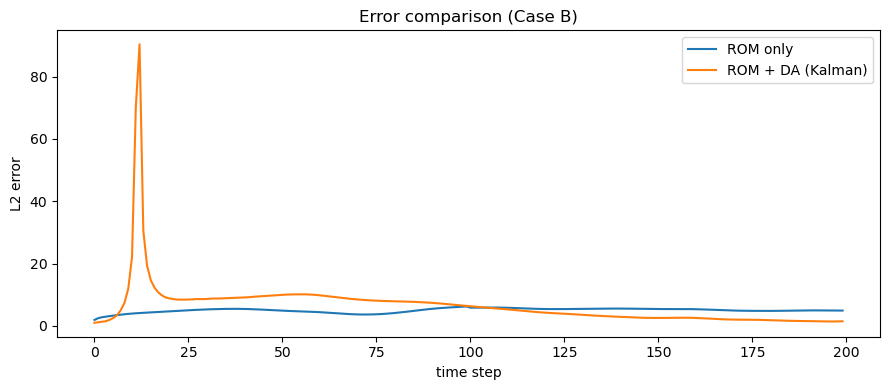

(array([1.93341387, 2.49927358, 2.8007467 , 2.99522029, 3.16184717,
        3.32329179, 3.47950448, 3.6256758 , 3.75834034, 3.8762538 ,
        3.97982724, 4.07051561, 4.15042021, 4.222025  , 4.28797054,
        4.35082684, 4.41287135, 4.47589826, 4.54108724, 4.60895102,
        4.67936673, 4.75168135, 4.82486897, 4.8977114 , 4.96897317,
        5.03754676, 5.10255141, 5.16337793, 5.21967976, 5.27131791,
        5.31827312, 5.360542  , 5.39803607, 5.43050119, 5.45747204,
        5.4782705 , 5.49204997, 5.49788106, 5.49486776, 5.48227945,
        5.45968186, 5.42705045, 5.38485079, 5.33407347, 5.27621452,
        5.21319668, 5.14723254, 5.08063753, 5.01560895, 4.95399572,
        4.89708964, 4.84547114, 4.79893697, 4.75652572, 4.71664005,
        4.67724804, 4.6361342 , 4.59116568, 4.54054186, 4.48300227,
        4.41797657, 4.34566822, 4.26706963, 4.18391067, 4.09854578,
        4.01378794, 3.93270205, 3.85837545, 3.79368948, 3.74112048,
        3.70259852, 3.67944488, 3.67239418, 3.68

In [82]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.1,
               init_error=False, use_inflation=False)


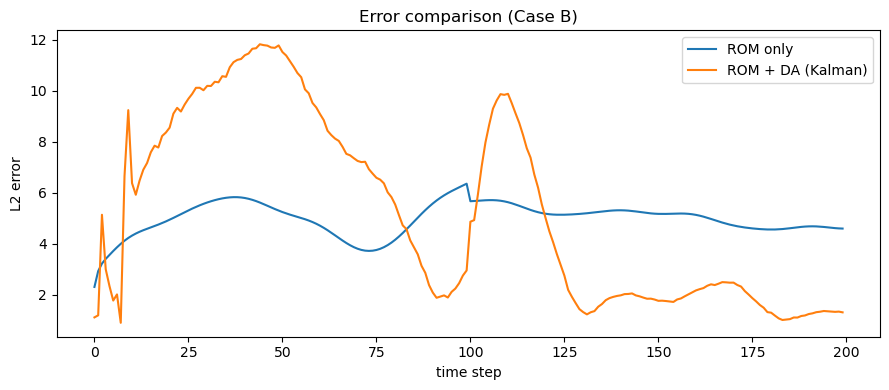

(array([2.29691604, 2.91965647, 3.21332466, 3.39742237, 3.55431403,
        3.70576394, 3.85171062, 3.98750495, 4.10973984, 4.21718216,
        4.31027363, 4.39054047, 4.46019364, 4.52185831, 4.57834174,
        4.63239972, 4.68650566, 4.74264771, 4.8021828 , 4.86576878,
        4.93338228, 5.00441448, 5.07782371, 5.1523166 , 5.22652793,
        5.29917388, 5.36916118, 5.43564335, 5.49802428, 5.55591622,
        5.60906502, 5.65725904, 5.70023936, 5.73762784, 5.76888671,
        5.79331763, 5.81010243, 5.81838106, 5.81735713, 5.80641725,
        5.7852488 , 5.75394009, 5.71304876, 5.66362639, 5.60719077,
        5.54564222, 5.48112547, 5.41584617, 5.35185837, 5.29084733,
        5.2339367 , 5.18155037, 5.13335308, 5.08828309, 5.04467423,
        5.00045079, 4.95336754, 4.90126381, 4.84230227, 4.77516966,
        4.69922429, 4.61458279, 4.52214397, 4.42355218, 4.32110508,
        4.21761329, 4.11622211, 4.02020903, 3.93277468, 3.85684871,
        3.79493333, 3.74900381, 3.72047621, 3.71

In [83]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.05,
               init_error=False, use_inflation=True,
               inflation_factor=1.15, inflation_thresh=3.0)


## Qué hacemos AHORA (tu siguiente paso real)

Aquí es donde ya estás listo para avanzar.

Vamos a pasar de este toy problem a un pseudo-cylinder sin CFD duro todavía:

➤ Fase 2, parte A — Modelo simple de shedding oscilatorio

    (sin CFD, pero con estructura de vórtices)

➤ Fase 2, parte B — ROM del shedding
➤ Fase 2, parte C — DA con sensores en pared del cilindro
➤ Fase 3 — CFD

## A1 - Generar snapshots con un oscilador de Stuart-LAndau

Modelo continuo:

$$
\dot{a} = (\sigma + i\omega)a-(1+ic)|a|^2a
$$
- $a(t)$ complejo (amplituyd del modo inestable)
- $\sigma > 0 $ crecimiento lineal
- $\omega$ frecuencia
- $c$ no linealidades de fase
Discretizamos con Euler explícito (suficiente para este nivel)


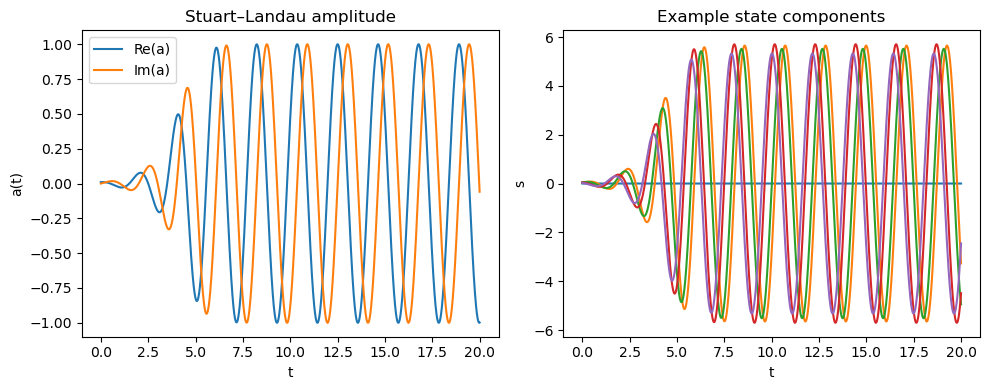

In [84]:
def generate_stuart_landau_snapshots(
    n_state=50,
    n_steps=200000,     # enough time
    dt=1e-4,            # stable integration
    sigma=1.0,
    omega=2*np.pi*0.5,
    c=0.2,
    noise_std=0.0,
):
    t = np.linspace(0, (n_steps-1)*dt, n_steps)

    a = np.zeros(n_steps, dtype=complex)
    a[0] = 0.01 + 0j

    for k in range(n_steps-1):
        a_k = a[k]
        nonlin = (sigma + 1j*omega)*a_k - (1 + 1j*c)*(abs(a_k)**2)*a_k
        a[k+1] = a_k + dt * nonlin

    x = np.linspace(0, 1, n_state)
    phi1 = np.sin(np.pi * x)
    phi2 = np.sin(2*np.pi * x)

    snapshots = np.zeros((n_state, n_steps))
    for k in range(n_steps):
        snapshots[:, k] = np.real(a[k])*phi1 + np.imag(a[k])*phi2

    # scale to manageable magnitude
    snapshots *= 5  

    return snapshots, dt, t, a, x, phi1, phi2


# --- Generar y visualizar ---
snapshots_SL, dt_SL, t_SL, a_SL, x_SL, phi1_SL, phi2_SL = generate_stuart_landau_snapshots()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t_SL, np.real(a_SL), label="Re(a)")
plt.plot(t_SL, np.imag(a_SL), label="Im(a)")
plt.xlabel("t")
plt.ylabel("a(t)")
plt.title("Stuart–Landau amplitude")
plt.legend()

plt.subplot(1,2,2)
for idx in [0, 10, 20, 30, 40]:
    plt.plot(t_SL, snapshots_SL[idx, :], label=f"state {idx}")
plt.xlabel("t")
plt.ylabel("s")
plt.title("Example state components")
plt.tight_layout()
plt.show()


## A2 - Reutilizar la pipeline ROM+DA sobre este nuevo flujo

Aquí viene lo importante: no hace falta inventarse otro pipeline.
run_test_caseB es, en realidad, run_trast generic: solo depende de snapshots y dt.

Asçi que ahora, para testear Stuart-Landau, lo único que tienes que hacer es:

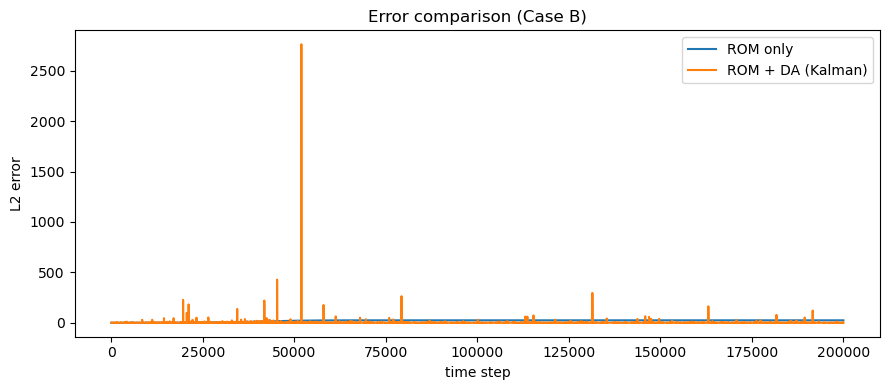

In [85]:
err_rom_SL, err_da_SL = run_test_caseB(
    snapshots_SL,
    dt_SL,
    r_rank=10,
    b_std=1e-3,
    r_std=0.05,
    init_error=False,
    use_inflation=True,      # yo lo dejaría ya ON por defecto
    inflation_factor=1.15,
    inflation_thresh=3.0,
    noise_std=0.05,
)


La primera figura es correcta y lo que esperaba ver:

Crecimiento exponencial inicial

Saturación clara en amplitud ≈ 1

Oscilación estable en ciclo límite

Campos espaciales creciendo con la misma dinámica

Bien.
Ya podemos trabajar sobre un sistema NO lineal real.

Pero la segunda gráfica (ROM vs DA) deja claro que tu pipeline NO está preparado para este tipo de dinámica, y te voy a explicar exactamente por qué y qué hacer.

In [86]:
# Partimos de snapshots_SL, dt_SL, t_SL generados antes

stride = 100  # coge una de cada 100 muestras
snapshots_SL_sub = snapshots_SL[:, ::stride]
dt_SL_sub = dt_SL * stride
t_SL_sub = t_SL[::stride]

print("Original steps:", snapshots_SL.shape[1])
print("Subsampled steps:", snapshots_SL_sub.shape[1])


Original steps: 200000
Subsampled steps: 2000


In [87]:
def build_delay_snapshots(snapshots, q_delays):
    """
    snapshots: (n_state, n_steps)
    q_delays: número de retardos (incluyendo el presente)
    Devuelve:
        Xd: (n_state * q_delays, n_steps - q_delays + 1)
    """
    n_state, n_steps = snapshots.shape
    n_cols = n_steps - q_delays + 1
    Xd = np.zeros((n_state * q_delays, n_cols))

    for k in range(n_cols):
        block = snapshots[:, k:k+q_delays]   # (n_state, q)
        Xd[:, k] = block.reshape(-1, order="F")  # apilar columnas

    return Xd


In [88]:
class DelayDMDROM:
    def __init__(self):
        self.Phi = None
        self.eigs = None
        self.F = None
        self.r = None
        self.r0 = None
        self.dt = None
        self.q = None
        self.n_state = None

    def fit(self, snapshots, dt, q_delays=10, r=10):
        """
        snapshots: (n_state, n_steps)
        q_delays: nº de retardos
        r: rango truncado
        """
        self.n_state = snapshots.shape[0]
        self.q = q_delays
        self.dt = dt

        Xd = build_delay_snapshots(snapshots, q_delays)
        X = Xd[:, :-1]
        Xp = Xd[:, 1:]

        U, S, Vh = np.linalg.svd(X, full_matrices=False)
        U_r = U[:, :r]
        S_r = S[:r]
        V_r = Vh[:r, :]

        A_tilde = U_r.T @ Xp @ V_r.T @ np.diag(1.0 / S_r)
        eigs, W = np.linalg.eig(A_tilde)
        Phi_delay = Xp @ V_r.T @ np.diag(1.0 / S_r) @ W

        # opcional: estabilizar autovalores ligeramente dentro del círculo unidad
        eigs = np.array(eigs)
        mask = np.abs(eigs) > 1.0
        eigs[mask] = eigs[mask] / np.abs(eigs[mask])

        self.Phi = Phi_delay
        self.eigs = eigs
        self.F = np.diag(eigs)

        x0_delay = Xd[:, 0]
        r0 = np.linalg.lstsq(self.Phi, x0_delay, rcond=None)[0]
        self.r0 = r0.copy()
        self.r = r0.copy()

    def step(self):
        """
        Avanza un paso en el espacio reducido y reconstruye el estado físico actual.
        """
        self.r = self.F @ self.r
        delay_vec = self.Phi @ self.r   # (n_state * q,)
        s_rec = delay_vec[:self.n_state]
        return s_rec, self.r


In [89]:
def run_test_stuart_landau_delay(
    snapshots,
    dt,
    q_delays=10,
    r_rank=10,
    b_std=1e-3,
    r_std=0.1,
    init_error=False,
    use_inflation=True,
    inflation_factor=1.05,
    inflation_thresh=3.0,
    noise_std=0.05,
):
    n_state, n_steps = snapshots.shape

    # --- ROM con delay embedding ---
    rom = DelayDMDROM()
    rom.fit(snapshots, dt, q_delays=q_delays, r=r_rank)

    # número de pasos “útiles” del ROM
    n_steps_rom = n_steps - q_delays

    # --- Sensores: usamos datos a partir de t = q_delays*dt ---
    sensor_indices = [0, 10, 20]
    sensor_data_full = snapshots[sensor_indices, :]        # (n_sensors, n_steps)
    sensor_data = sensor_data_full[:, q_delays:]           # alineado con ROM

    n_sensors = len(sensor_indices)

    # Matriz de observación en espacio físico
    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0

    # Extender H_x al espacio con retardos (solo primer bloque)
    H_x_ext = np.zeros((n_sensors, n_state * rom.q))
    H_x_ext[:, :n_state] = H_x

    # Observación en espacio reducido
    H_tilde = H_x_ext @ rom.Phi   # (n_sensors, r_rank)

    # --- DA ---
    da = DataAssimilator(
        rom.F,
        H_tilde,
        b_std=b_std,
        r_std=r_std,
        use_inflation=use_inflation,
        inflation_factor=inflation_factor,
        inflation_thresh=inflation_thresh,
    )

    # estado inicial reducido
    if init_error:
        rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)
    else:
        rom.r = rom.r0.copy()

    # --- Loop DA “a mano” ---
    outputs_da = []
    # sensor source sencillo
    k_sensor = 0

    for k in range(n_steps_rom):
        # lectura de sensores
        y_true = sensor_data[:, k]
        y_noisy = y_true + noise_std * np.random.randn(*y_true.shape)

        # predicción ROM en espacio reducido
        rom.r = rom.F @ rom.r
        delay_vec_pred = rom.Phi @ rom.r
        s_pred = delay_vec_pred[:n_state]

        # actualización DA
        r_upd = da.update(rom.r, y_noisy)
        delay_vec_upd = rom.Phi @ r_upd
        s_rec = delay_vec_upd[:n_state]

        rom.r = r_upd
        outputs_da.append(s_rec)

    outputs_da = np.array(outputs_da)                  # (n_steps_rom, n_state)

    # Verdad alineada (desde q_delays)
    true = snapshots[:, q_delays:q_delays + n_steps_rom].T  # (n_steps_rom, n_state)

    err_da = np.linalg.norm(outputs_da - true, axis=1)

    # --- ROM-only baseline (delay-DMD, sin DA) ---
    rom2 = DelayDMDROM()
    rom2.fit(snapshots, dt, q_delays=q_delays, r=r_rank)
    if init_error:
        rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)
    else:
        rom2.r = rom2.r0.copy()

    outputs_rom = []
    for k in range(n_steps_rom):
        rom2.r = rom2.F @ rom2.r
        delay_vec = rom2.Phi @ rom2.r
        s_pred = delay_vec[:n_state]
        outputs_rom.append(s_pred)

    outputs_rom = np.array(outputs_rom)
    err_rom = np.linalg.norm(outputs_rom - true, axis=1)

    # --- Plot ---
    plt.figure(figsize=(9,4))
    plt.plot(err_rom, label="ROM only (delay-DMD)")
    plt.plot(err_da, label="ROM + DA (Kalman, delay)")
    plt.xlabel("time step")
    plt.ylabel("L2 error")
    plt.legend()
    plt.title("Error comparison (Stuart–Landau with delay-DMD)")
    plt.tight_layout()
    plt.show()

    return err_rom, err_da


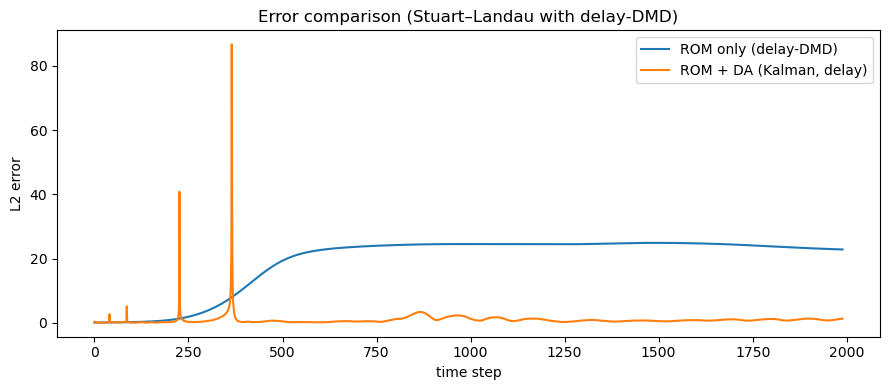

In [90]:
err_rom_SL, err_da_SL = run_test_stuart_landau_delay(
    snapshots_SL_sub,
    dt_SL_sub,
    q_delays=10,
    r_rank=10,
    b_std=1e-3,
    r_std=0.1,
    init_error=False,
    use_inflation=True,
    inflation_factor=1.05,
    inflation_thresh=3.0,
    noise_std=0.05,
)


Subir R y ver si los spikes desaparecen


=== r_std = 0.1 ===


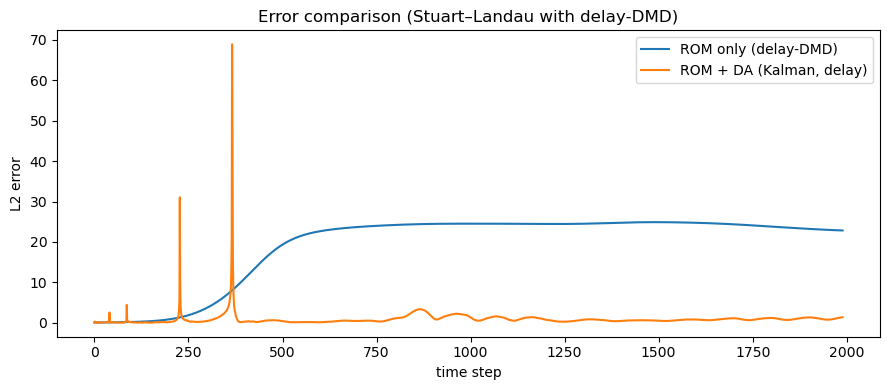

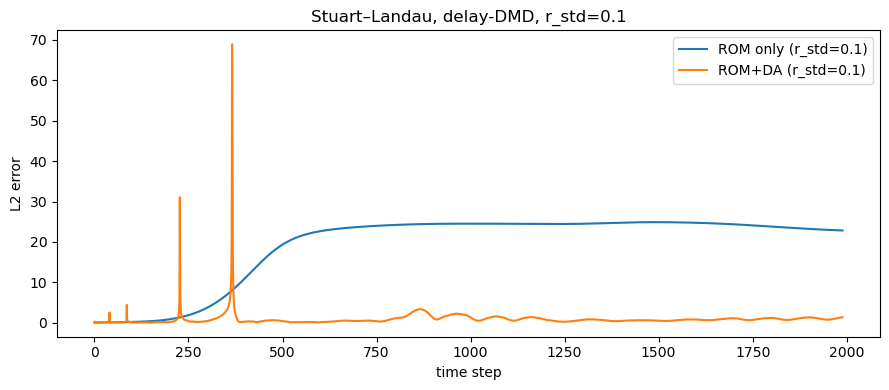


=== r_std = 0.3 ===


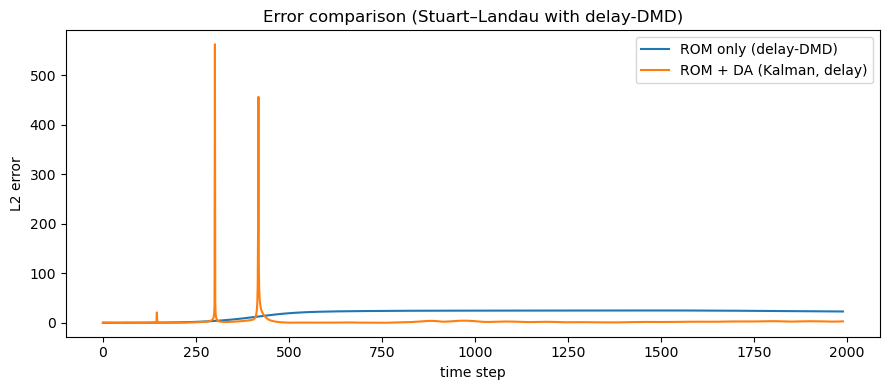

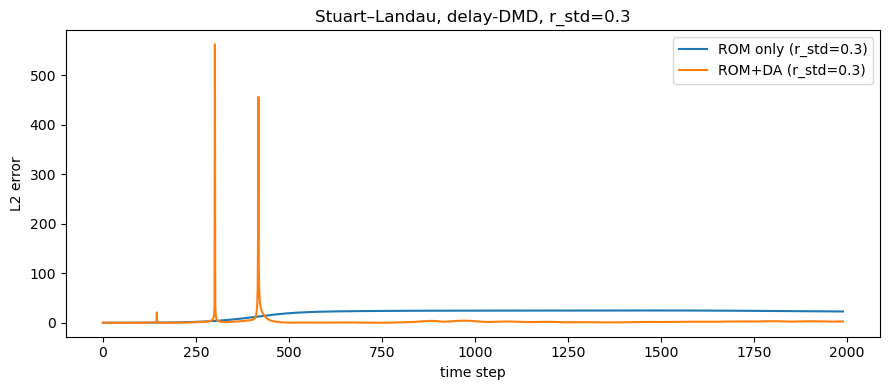


=== r_std = 0.5 ===


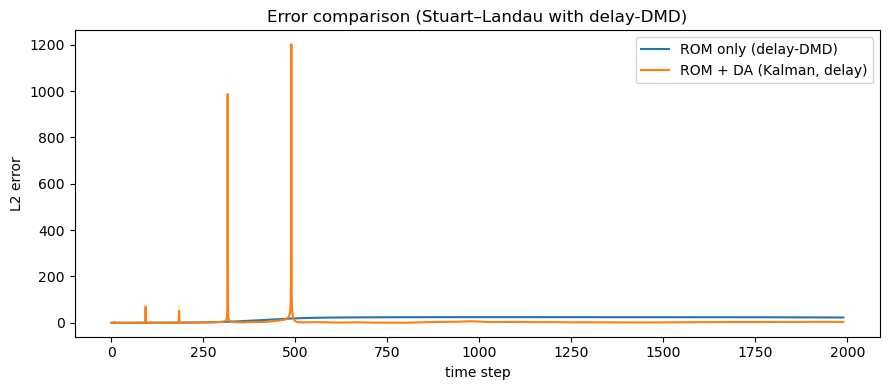

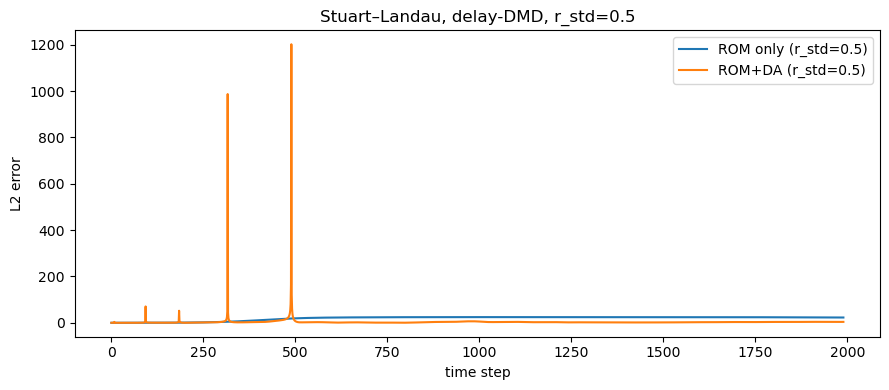


=== r_std = 1.0 ===


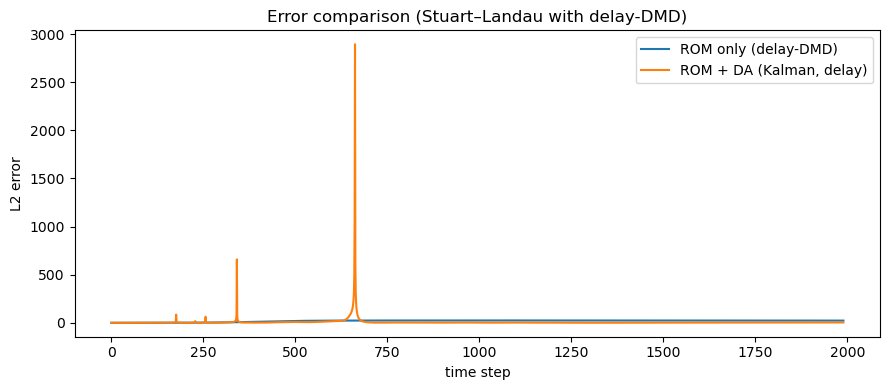

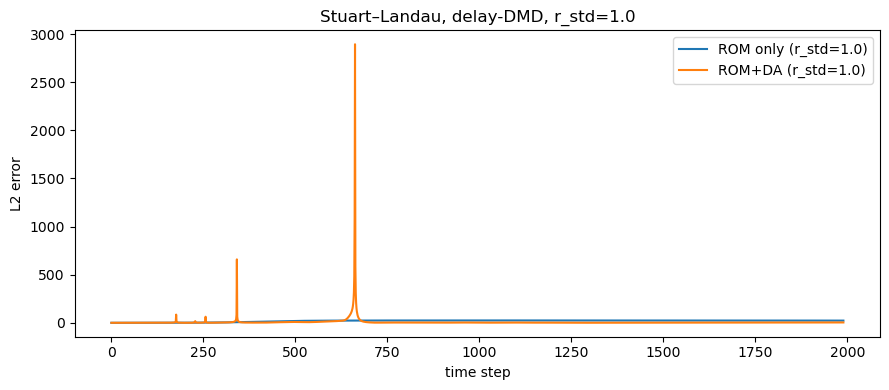

In [91]:
r_vals = [0.1, 0.3, 0.5, 1.0]

results_R = {}

for r_std in r_vals:
    print(f"\n=== r_std = {r_std} ===")
    err_rom_SL, err_da_SL = run_test_stuart_landau_delay(
        snapshots_SL_sub,
        dt_SL_sub,
        q_delays=10,
        r_rank=10,
        b_std=1e-3,
        r_std=r_std,
        init_error=False,
        use_inflation=True,
        inflation_factor=1.05,
        inflation_thresh=3.0,
        noise_std=0.05,
    )
    results_R[r_std] = (err_rom_SL, err_da_SL)

    plt.figure(figsize=(9,4))
    plt.plot(err_rom_SL, label=f"ROM only (r_std={r_std})")
    plt.plot(err_da_SL, label=f"ROM+DA (r_std={r_std})")
    plt.xlabel("time step")
    plt.ylabel("L2 error")
    plt.legend()
    plt.title(f"Stuart–Landau, delay-DMD, r_std={r_std}")
    plt.tight_layout()
    plt.show()


Añadir lifting EDMD polinomial (grado 2)

In [92]:
def lift_poly2(snapshots):
    """
    snapshots: (n_state, n_steps)
    Devuelve:
        G: (2*n_state, n_steps)  con [s; s^2]
    """
    s2 = snapshots**2
    return np.vstack([snapshots, s2])


class EDMDROM:
    """
    EDMD con lifting polinomial grado 2: g(s) = [s; s^2].
    ROM lineal en el espacio levantado, reconstrucción al espacio físico.
    """
    def __init__(self):
        self.Phi = None   # modos en espacio levantado
        self.eigs = None
        self.F = None     # propagador reducido
        self.r = None
        self.r0 = None
        self.dt = None
        self.n_state = None

    def fit(self, snapshots, dt, r=10):
        """
        snapshots: (n_state, n_steps)
        r: rango truncado
        """
        self.n_state, n_steps = snapshots.shape
        self.dt = dt

        G = lift_poly2(snapshots)
        X = G[:, :-1]
        Xp = G[:, 1:]

        U, S, Vh = np.linalg.svd(X, full_matrices=False)
        U_r = U[:, :r]
        S_r = S[:r]
        V_r = Vh[:r, :]

        A_tilde = U_r.T @ Xp @ V_r.T @ np.diag(1.0 / S_r)
        eigs, W = np.linalg.eig(A_tilde)
        Phi = Xp @ V_r.T @ np.diag(1.0 / S_r) @ W

        # estabilizar autovalores levemente dentro del círculo unidad
        eigs = np.array(eigs)
        mask = np.abs(eigs) > 1.0
        eigs[mask] = eigs[mask] / np.abs(eigs[mask])

        self.Phi = Phi
        self.eigs = eigs
        self.F = np.diag(eigs)

        g0 = G[:, 0]
        r0 = np.linalg.lstsq(self.Phi, g0, rcond=None)[0]
        self.r0 = r0.copy()
        self.r = r0.copy()

    def step(self):
        """Propaga en espacio reducido y devuelve estado físico reconstruido."""
        self.r = self.F @ self.r
        g_rec = self.Phi @ self.r      # espacio levantado
        s_rec = g_rec[:self.n_state]   # primera mitad = estado físico
        return s_rec, self.r


test EDMD + Kalman (sin delays, para simplificar)

In [93]:
def run_test_stuart_landau_edmd(
    snapshots,
    dt,
    r_rank=10,
    b_std=1e-3,
    r_std=0.3,
    init_error=False,
    use_inflation=True,
    inflation_factor=1.05,
    inflation_thresh=3.0,
    noise_std=0.05,
):
    n_state, n_steps = snapshots.shape

    # --- ROM EDMD ---
    rom = EDMDROM()
    rom.fit(snapshots, dt, r=r_rank)

    # --- Sensores ---
    sensor_indices = [0, 10, 20]
    sensor_data = snapshots[sensor_indices, :]
    n_sensors = len(sensor_indices)

    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0

    # observación en espacio levantado: sólo mide la parte física de g(s)
    n_lift = rom.Phi.shape[0]
    H_lift = np.zeros((n_sensors, n_lift))
    H_lift[:, :n_state] = H_x

    H_tilde = H_lift @ rom.Phi  # (n_sensors, r_rank)

    da = DataAssimilator(
        rom.F,
        H_tilde,
        b_std=b_std,
        r_std=r_std,
        use_inflation=use_inflation,
        inflation_factor=inflation_factor,
        inflation_thresh=inflation_thresh,
    )

    if init_error:
        rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)
    else:
        rom.r = rom.r0.copy()

    # --- Loop DA ---
    outputs_da = []
    for k in range(n_steps-1):
        # medición
        y_true = sensor_data[:, k+1]   # un paso adelante
        y_noisy = y_true + noise_std * np.random.randn(*y_true.shape)

        # predicción modelo
        s_pred, r_pred = rom.step()

        # actualización DA
        r_upd = da.update(r_pred, y_noisy)
        g_rec = rom.Phi @ r_upd
        s_rec = g_rec[:n_state]

        rom.r = r_upd
        outputs_da.append(s_rec)

    outputs_da = np.array(outputs_da)                   # (n_steps-1, n_state)
    true = snapshots[:, 1:].T                          # (n_steps-1, n_state)
    err_da = np.linalg.norm(outputs_da - true, axis=1)

    # --- ROM-only ---
    rom2 = EDMDROM()
    rom2.fit(snapshots, dt, r=r_rank)
    if init_error:
        rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)
    else:
        rom2.r = rom2.r0.copy()

    outputs_rom = []
    for k in range(n_steps-1):
        s_pred, r_pred = rom2.step()
        outputs_rom.append(s_pred)

    outputs_rom = np.array(outputs_rom)
    err_rom = np.linalg.norm(outputs_rom - true, axis=1)

    plt.figure(figsize=(9,4))
    plt.plot(err_rom, label="ROM only (EDMD)")
    plt.plot(err_da, label="ROM + DA (EDMD)")
    plt.xlabel("time step")
    plt.ylabel("L2 error")
    plt.legend()
    plt.title("Stuart–Landau with EDMD (poly2) + DA")
    plt.tight_layout()
    plt.show()

    return err_rom, err_da


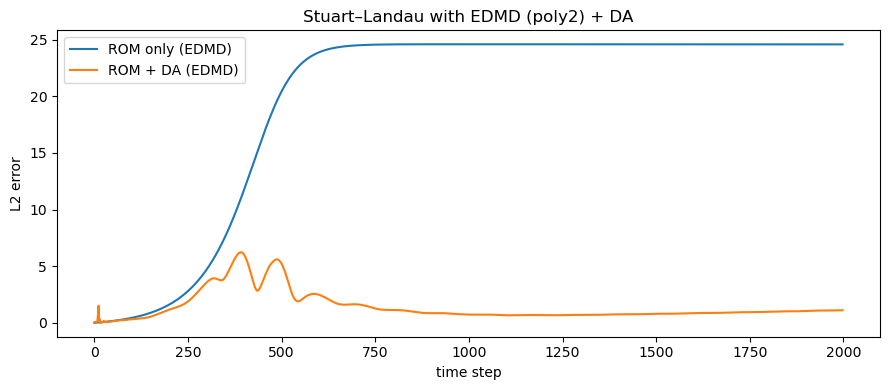

In [94]:
# snapshots_SL_sub: (n_state, n_steps_sub)
err_rom_EDMD, err_da_EDMD = run_test_stuart_landau_edmd(
    snapshots_SL_sub,
    dt_SL_sub,
    r_rank=10,
    b_std=1e-3,
    r_std=0.3,       # usa un valor de R que hayas visto razonable en el barrido
    init_error=False,
    use_inflation=True,
    inflation_factor=1.05,
    inflation_thresh=3.0,
    noise_std=0.05,
)


Implementar un UKF en el espacio reducido

In [98]:
class UKFAssimilator:
    def __init__(
        self,
        F,              # propagador en espacio reducido (r x r), posiblemente complejo
        H_tilde,        # observación en espacio reducido (n_sensors x r)
        b_std=1e-3,
        r_std=0.3,
        alpha=1e-3,
        beta=2.0,
        kappa=0.0,
    ):
        self.F = F
        self.H = H_tilde
        self.r = None   # estado reducido actual

        n = F.shape[0]
        self.n = n

        # Tipo: si F es complejo, todo el filtro es complejo
        if np.iscomplexobj(F):
            dtype = np.complex128
        else:
            dtype = np.float64

        self.B = (b_std**2) * np.eye(n, dtype=dtype)
        self.R = (r_std**2) * np.eye(H_tilde.shape[0], dtype=dtype)
        self.P = np.eye(n, dtype=dtype) * 1.0

        # parámetros UKF
        self.alpha = alpha
        self.beta = beta
        self.kappa = kappa
        self.lambda_ = alpha**2 * (n + kappa) - n

        self.Wm, self.Wc = self._compute_weights(dtype)

    def _compute_weights(self, dtype):
        n = self.n
        lam = self.lambda_
        Wm = np.zeros(2*n + 1, dtype=dtype)
        Wc = np.zeros(2*n + 1, dtype=dtype)
        Wm[0] = lam / (n + lam)
        Wc[0] = lam / (n + lam) + (1 - self.alpha**2 + self.beta)
        for i in range(1, 2*n + 1):
            Wm[i] = 1.0 / (2*(n + lam))
            Wc[i] = 1.0 / (2*(n + lam))
        return Wm, Wc

    def _sigma_points(self, r, P):
        n = self.n
        lam = self.lambda_
        sigma_points = np.zeros((2*n + 1, n), dtype=P.dtype)
        sigma_points[0] = r

        # Cholesky para matriz (posiblemente) compleja
        sqrt_mat = np.linalg.cholesky((n + lam)*P)
        for i in range(n):
            sigma_points[i+1]     = r + sqrt_mat[:, i]
            sigma_points[n+i+1]   = r - sqrt_mat[:, i]
        return sigma_points

    def predict(self):
        """Predicción UKF: dinámica lineal r_{k+1} = F r_k."""
        sigma = self._sigma_points(self.r, self.P)

        sigma_pred = (self.F @ sigma.T).T

        r_pred = np.sum(self.Wm[:, None] * sigma_pred, axis=0)

        P_pred = np.zeros((self.n, self.n), dtype=self.P.dtype)
        for i in range(2*self.n + 1):
            diff = sigma_pred[i] - r_pred
            P_pred += self.Wc[i] * np.outer(diff, diff.conj())
        P_pred += self.B

        self.r = r_pred
        self.P = P_pred

    def update(self, y_obs):
        """
        Observación lineal y = H r + ruido.
        y_obs se asume real; lo convertimos al mismo tipo si hace falta.
        """
        if np.iscomplexobj(self.P):
            y_obs = y_obs.astype(np.complex128)

        sigma = self._sigma_points(self.r, self.P)
        Y = (self.H @ sigma.T).T   # (2n+1, n_sensors)

        y_pred = np.sum(self.Wm[:, None] * Y, axis=0)

        n_sensors = self.H.shape[0]
        P_yy = np.zeros((n_sensors, n_sensors), dtype=self.P.dtype)
        P_xy = np.zeros((self.n, n_sensors), dtype=self.P.dtype)

        for i in range(2*self.n + 1):
            dy = Y[i] - y_pred
            dx = sigma[i] - self.r
            P_yy += self.Wc[i] * np.outer(dy, dy.conj())
            P_xy += self.Wc[i] * np.outer(dx, dy.conj())
        P_yy += self.R

        K = P_xy @ np.linalg.inv(P_yy)

        innovation = y_obs - y_pred
        self.r = self.r + K @ innovation
        self.P = self.P - K @ P_yy @ K.T.conj()

        return self.r



Celda: test EDMD + UKF

In [99]:
def run_test_stuart_landau_edmd_ukf(
    snapshots,
    dt,
    r_rank=10,
    b_std=1e-3,
    r_std=0.3,
    noise_std=0.05,
):
    n_state, n_steps = snapshots.shape

    # --- ROM EDMD ---
    rom = EDMDROM()
    rom.fit(snapshots, dt, r=r_rank)

    sensor_indices = [0, 10, 20]
    sensor_data = snapshots[sensor_indices, :]
    n_sensors = len(sensor_indices)

    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0

    n_lift = rom.Phi.shape[0]
    H_lift = np.zeros((n_sensors, n_lift))
    H_lift[:, :n_state] = H_x

    H_tilde = H_lift @ rom.Phi  # (n_sensors, r_rank)

    # --- UKF ---
    ukf = UKFAssimilator(
        rom.F,
        H_tilde,
        b_std=b_std,
        r_std=r_std,
        alpha=1e-3,
        beta=2.0,
        kappa=0.0,
    )
    ukf.r = rom.r0.copy()

    # --- Loop UKF ---
    outputs_da = []
    r = ukf.r.copy()

    for k in range(n_steps-1):
        y_true = sensor_data[:, k+1]
        y_noisy = y_true + noise_std * np.random.randn(*y_true.shape)

        ukf.predict()
        r_upd = ukf.update(y_noisy)

        g_rec = rom.Phi @ r_upd
        s_rec = g_rec[:n_state]
        outputs_da.append(s_rec)

    outputs_da = np.array(outputs_da)
    true = snapshots[:, 1:].T
    err_da = np.linalg.norm(outputs_da - true, axis=1)

    # --- ROM-only ---
    rom2 = EDMDROM()
    rom2.fit(snapshots, dt, r=r_rank)
    rom2.r = rom2.r0.copy()
    outputs_rom = []
    for k in range(n_steps-1):
        s_pred, _ = rom2.step()
        outputs_rom.append(s_pred)
    outputs_rom = np.array(outputs_rom)
    err_rom = np.linalg.norm(outputs_rom - true, axis=1)

    plt.figure(figsize=(9,4))
    plt.plot(err_rom, label="ROM only (EDMD)")
    plt.plot(err_da, label="ROM + UKF (EDMD)")
    plt.xlabel("time step")
    plt.ylabel("L2 error")
    plt.legend()
    plt.title("Stuart–Landau with EDMD + UKF")
    plt.tight_layout()
    plt.show()

    return err_rom, err_da


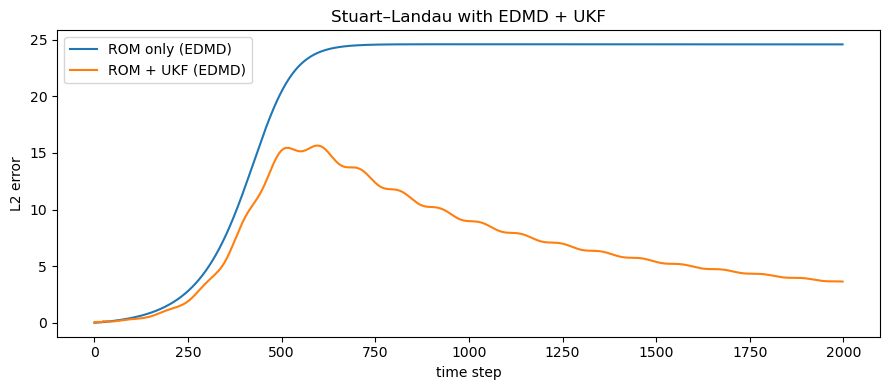

In [100]:
err_rom_EDMD_ukf, err_da_EDMD_ukf = run_test_stuart_landau_edmd_ukf(
    snapshots_SL_sub,
    dt_SL_sub,
    r_rank=10,
    b_std=1e-3,
    r_std=0.3,
    noise_std=0.05,
)
